# Projeto de Parceria | Semantix
## Detecção de Fraudes com SVM e XGBoost



## Objetivo
Este projeto tem como objetivo comparar o desempenho dos modelos SVM e XGBoost na detecção de fraudes em transações de cartão de crédito, utilizando uma base de dados pública e aplicando técnicas adequadas para lidar com desbalanceamento de classes.

## 1. Importação das bibliotecas


In [1]:
!pip install -q xgboost imbalanced-learn

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

## 2. Coleta de dados
Foi utilizada a base pública **Credit Card Fraud Detection**, disponível no Kaggle.  
O conjunto de dados contém transações realizadas por cartões de crédito, com o objetivo de classificar cada operação como legítima ou fraudulenta.

A variável alvo é `Class`, em que:
- `0` representa transações normais
- `1` representa fraudes

In [3]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Inspeção inicial da base
Nesta etapa, são verificadas a estrutura da base, o tipo das variáveis, a quantidade de registros e a presença de valores ausentes.

In [4]:
print("Dimensões da base:", df.shape)
display(df.head())
display(df.info())
display(df.describe())

Dimensões da base: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Estatísticas descritivas

A análise estatística mostra que:

- As variáveis `V1` a `V28` possuem média próxima de zero, o que é esperado devido à aplicação do PCA
- Os valores mínimos e máximos indicam a presença de possíveis **outliers**
- A variável `Amount` apresenta grande variação, indicando diferentes perfis de transação
- A variável `Time` também apresenta ampla dispersão ao longo do período analisado

Essas características indicam a necessidade de **padronização dos dados**, especialmente para algoritmos sensíveis à escala, como o SVM.

In [5]:
df["Class"].value_counts()
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


## 4. Análise do desbalanceamento das classes

A análise da variável alvo (`Class`) evidencia um forte desbalanceamento na base de dados:

- **99,83%** das transações são normais (classe 0)
- **0,17%** das transações são fraudes (classe 1)

Esse cenário caracteriza um problema de **classificação altamente desbalanceada**, comum em aplicações reais como detecção de fraudes.

### Impacto no modelo

Esse desbalanceamento traz desafios importantes:

- Um modelo pode alcançar alta **acurácia** simplesmente prevendo todas as transações como normais
- Isso resultaria em um modelo inútil para o objetivo do projeto, que é detectar fraudes

### Métricas adequadas

Diante disso, métricas como **acurácia isoladamente não são suficientes**.  
As métricas mais relevantes neste contexto são:

- **Recall**: capacidade de identificar fraudes
- **Precisão**: proporção de fraudes corretamente identificadas
- **F1-score**: equilíbrio entre precisão e recall
- **ROC-AUC**: capacidade geral de separação entre classes
- **PR-AUC**: especialmente importante para dados desbalanceados

### Estratégia adotada

Para lidar com esse problema, serão utilizadas técnicas específicas:

- **SMOTE (oversampling)** para aumentar a classe minoritária no conjunto de treino
- Uso de métricas apropriadas para avaliação
- Comparação entre modelos com foco na detecção da classe fraudulenta

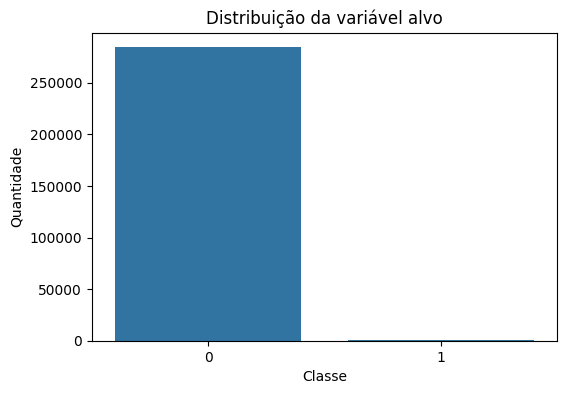

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Class")
plt.title("Distribuição da variável alvo")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

## Visualização da distribuição das classes

O gráfico acima evidencia de forma clara o forte desbalanceamento entre as classes.

Observa-se que a grande maioria das transações pertence à classe 0 (transações normais), enquanto a classe 1 (fraudes) representa uma parcela extremamente pequena do total.

Essa diferença significativa reforça o desafio do problema, uma vez que modelos de Machine Learning podem apresentar alto desempenho aparente ao simplesmente prever a classe majoritária.

Dessa forma, torna-se essencial o uso de métricas apropriadas e técnicas específicas para lidar com esse tipo de distribuição, garantindo que o modelo seja capaz de identificar corretamente as transações fraudulentas.

### 6. Distribuição do valor das transações (Amount) ##

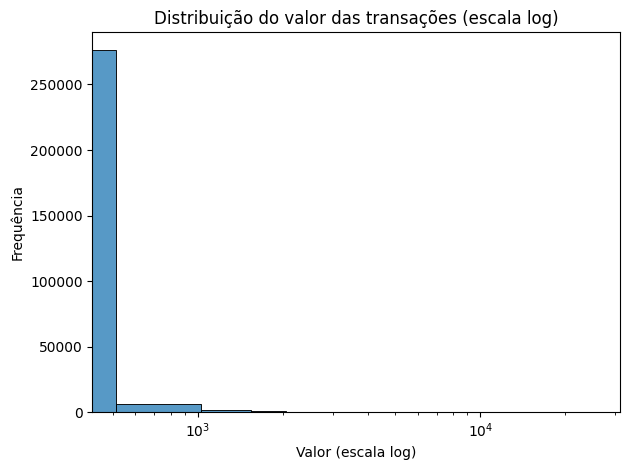

In [11]:
sns.histplot(df["Amount"], bins=50)
plt.xscale('log')
plt.title("Distribuição do valor das transações (escala log)")
plt.xlabel("Valor (escala log)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

## Distribuição do valor das transações (escala logarítmica)

A aplicação da escala logarítmica permitiu uma melhor visualização da distribuição da variável `Amount`.

Observa-se que a maioria das transações está concentrada em valores baixos, enquanto uma pequena parcela apresenta valores significativamente mais elevados.

Essa distribuição assimétrica é característica comum em dados financeiros e evidencia a presença de outliers. A transformação logarítmica foi essencial para revelar padrões que não eram visíveis na escala original.

## 2. Distribuição da variável Time ##

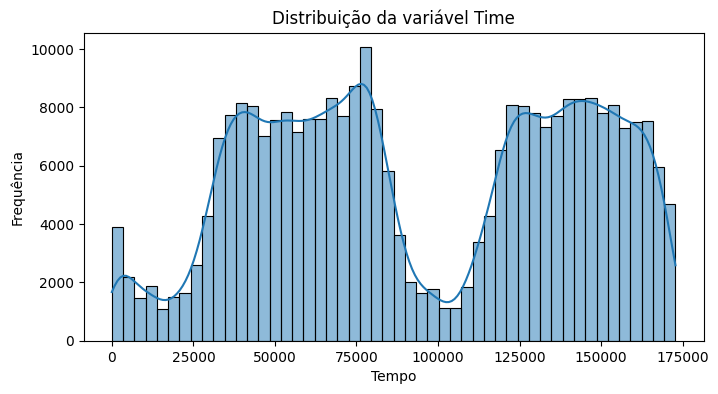

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(df["Time"], bins=50, kde=True)
plt.title("Distribuição da variável Time")
plt.xlabel("Tempo")
plt.ylabel("Frequência")
plt.show()

## Distribuição da variável Time

A variável `Time` representa o tempo decorrido desde a primeira transação registrada.

A análise da distribuição mostra que as transações estão distribuídas ao longo de todo o período observado, sem concentração extrema em um único intervalo.

Observa-se uma leve variação na densidade das transações ao longo do tempo, o que pode indicar padrões comportamentais ou ciclos de atividade.

No entanto, não há evidências claras de que a variável `Time`, isoladamente, seja suficiente para diferenciar transações fraudulentas das normais, sendo necessário combiná-la com outras variáveis para uma melhor capacidade preditiva.

## 3. Boxplot de Amount por classe ##

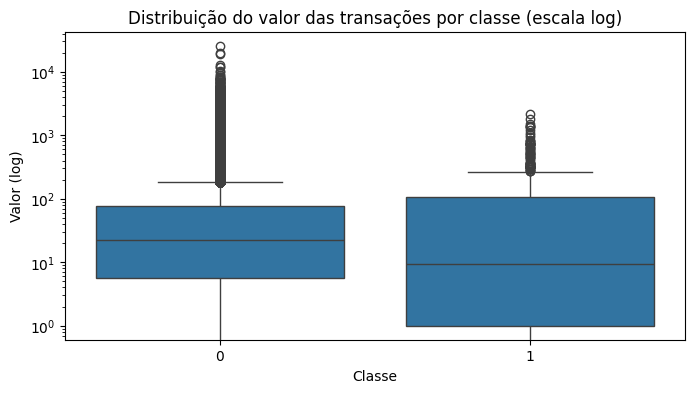

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Class", y="Amount")
plt.yscale('log')
plt.title("Distribuição do valor das transações por classe (escala log)")
plt.xlabel("Classe")
plt.ylabel("Valor (log)")
plt.show()

## Distribuição do valor das transações por classe (escala logarítmica)

A aplicação da escala logarítmica permitiu uma visualização mais clara das diferenças entre as classes.

Observa-se que as transações normais (classe 0) apresentam maior dispersão e valores mais elevados, com presença significativa de outliers.

Por outro lado, as transações fraudulentas (classe 1) tendem a apresentar valores mais baixos e maior concentração em faixas específicas.

Esse comportamento sugere que fraudes não estão necessariamente associadas a altos valores, podendo ocorrer com frequência em transações menores.

Apesar dessas diferenças, ainda há sobreposição entre as classes, indicando que a variável `Amount` isoladamente não é suficiente para separar completamente fraudes de transações legítimas.

## 9. Preparação dos dados

Nesta etapa, os dados são separados entre variáveis preditoras (X) e variável alvo (y).

In [14]:
X = df.drop("Class", axis=1)
y = df["Class"]

## 10. Divisão treino e teste ##

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (227845, 30)
Teste: (56962, 30)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Tratamento do desbalanceamento (SMOTE) ##

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Antes do SMOTE:")
print(y_train.value_counts())

print("\nDepois do SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Antes do SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Depois do SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


## Tratamento do desbalanceamento com SMOTE

Para lidar com o forte desbalanceamento da base, foi aplicada a técnica SMOTE (Synthetic Minority Over-sampling Technique) no conjunto de treino.

Antes da aplicação do SMOTE, a classe fraudulenta representava uma parcela muito pequena dos dados. Após a aplicação da técnica, as classes foram balanceadas, permitindo que o modelo aprenda de forma mais eficaz os padrões associados às fraudes.

É importante destacar que o SMOTE foi aplicado apenas no conjunto de treino, evitando vazamento de informação para o conjunto de teste.

## Amostragem para viabilizar o SVM ##

porque o SVM é caro computacionalmente e o
dataset ficou grande com SMOTE

In [18]:
train_smote_df = pd.DataFrame(X_train_smote, columns=X.columns)
train_smote_df["Class"] = y_train_smote

sample_size = 12000

fraud = train_smote_df[train_smote_df["Class"] == 1].sample(n=sample_size, random_state=42)
normal = train_smote_df[train_smote_df["Class"] == 0].sample(n=sample_size, random_state=42)

train_sample = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

X_train_final = train_sample.drop("Class", axis=1)
y_train_final = train_sample["Class"]

print(X_train_final.shape)
print(y_train_final.value_counts())

(24000, 30)
Class
1    12000
0    12000
Name: count, dtype: int64


## Amostragem para viabilizar o SVM

Após a aplicação do SMOTE, o conjunto de treino tornou-se significativamente maior, o que pode impactar o desempenho computacional de modelos como o SVM.

Para contornar esse problema, foi realizada uma amostragem balanceada do conjunto de treino, selecionando uma quantidade igual de registros de cada classe.

O conjunto final utilizado para treinamento contém 24.000 registros, sendo 12.000 de cada classe, garantindo equilíbrio e viabilidade computacional.

## 11. SVM ##

In [19]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_final, y_train_final)

SVC(class_weight='balanced', probability=True, random_state=42)

In [21]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

## 12. XGBoost ##

In [22]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_final, y_train_final)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [23]:
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

## 13. Avaliação dos modelos

Para avaliar o desempenho dos modelos, foram utilizadas métricas adequadas para problemas de classificação desbalanceada, com foco especial na capacidade de identificar fraudes.

As métricas analisadas foram:

- Acurácia
- Precisão
- Recall
- F1-score
- ROC-AUC
- PR-AUC

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def avaliar_modelo(y_true, y_pred, y_prob, nome_modelo):
    return {
        "Modelo": nome_modelo,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }

resultado_svm = avaliar_modelo(y_test, y_pred_svm, y_prob_svm, "SVM")
resultado_xgb = avaliar_modelo(y_test, y_pred_xgb, y_prob_xgb, "XGBoost")

resultados = pd.DataFrame([resultado_svm, resultado_xgb])
resultados

,Modelo,Acurácia,Precisão,Recall,F1-score,ROC-AUC,PR-AUC
0,SVM,0.977353,0.064327,0.897959,0.120055,0.980525,0.490286
1,XGBoost,0.996226,0.300341,0.897959,0.450128,0.984240,0.753995


## Conclusão

Neste projeto, foi realizada a comparação entre os modelos SVM e XGBoost na detecção de fraudes em transações de cartão de crédito.

Ambos os modelos apresentaram alta capacidade de identificar fraudes, com valores de recall próximos de 0,90, o que é essencial em problemas desse tipo. No entanto, observou-se uma diferença significativa na precisão dos modelos.

O SVM apresentou baixa precisão, indicando um grande número de falsos positivos, o que pode gerar custos operacionais elevados em aplicações reais. Por outro lado, o modelo XGBoost apresentou desempenho superior, com maior precisão, F1-score e PR-AUC, demonstrando melhor equilíbrio entre detecção de fraudes e redução de alarmes falsos.

Dessa forma, o XGBoost se mostrou mais adequado para o problema proposto, sendo capaz de identificar fraudes de forma mais eficiente e confiável.

Este estudo reforça a importância de utilizar métricas adequadas em bases desbalanceadas e demonstra que a escolha do modelo deve considerar não apenas a acurácia, mas principalmente sua capacidade de lidar com a classe minoritária.

## Ajuste de threshold ##

In [25]:
threshold = 0.3

y_pred_xgb_adjusted = (y_prob_xgb >= threshold).astype(int)

In [26]:
avaliar_modelo(y_test, y_pred_xgb_adjusted, y_prob_xgb, "XGBoost ajustado")

{'Modelo': 'XGBoost ajustado',
 'Acurácia': 0.9928022190232084,
 'Precisão': 0.1816326530612245,
 'Recall': 0.9081632653061225,
 'F1-score': 0.30272108843537415,
 'ROC-AUC': np.float64(0.984239607139986),
 'PR-AUC': np.float64(0.7539952831934471)}

## Ajuste de threshold

Foi realizado o ajuste do threshold do modelo XGBoost, reduzindo o valor padrão de 0.5 para 0.3.

Essa alteração aumentou a sensibilidade do modelo, resultando em maior recall, ou seja, maior capacidade de identificar transações fraudulentas.

Como consequência, houve redução na precisão, indicando aumento de falsos positivos.

Esse comportamento representa um trade-off comum em problemas de detecção de fraude, onde, em muitos casos, é preferível identificar o maior número possível de fraudes, mesmo ao custo de gerar mais alertas incorretos.

A escolha do threshold ideal depende do contexto de negócio e dos custos associados a falsos positivos e falsos negativos.